# Train-Test-Validation Split Based on Time

This notebook performs a time-based split of the financial fraud dataset into training, validation, and test sets.

**Why time-based split?**
- Prevents data leakage from future to past
- Better simulates real-world deployment scenarios
- Essential for time-series or temporal data

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## Load Dataset

In [2]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

/Users/angjiayi/code/DSA4263/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [3]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print("Shape:", df.shape)
print(df.head())
print(df.info())

Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        

## Explore Temporal Distribution

**Note:** In this dataset, `step` represents time in hours. We'll convert it to days for easier interpretation (1 day = 24 steps/hours).

In [4]:
# Convert step (hours) to days
# In this dataset: 1 step = 1 hour, so 24 steps = 1 day
df['day'] = df['step'] / 24

print(f"Time range (steps/hours): {df['step'].min()} to {df['step'].max()}")

print(f"Time range (days): {df['day'].min():.2f} to {df['day'].max():.2f}")
print(df['day'].describe())

print(f"Total time steps: {df['step'].nunique()}")
print(f"\nDay statistics:")
print(f"Total days: {df['day'].max():.1f}")

Time range (steps/hours): 1 to 743
Time range (days): 0.04 to 30.96
count    6.362620e+06
mean     1.014155e+01
std      5.930499e+00
min      4.166667e-02
25%      6.500000e+00
50%      9.958333e+00
75%      1.395833e+01
max      3.095833e+01
Name: day, dtype: float64
Total time steps: 743

Day statistics:
Total days: 31.0


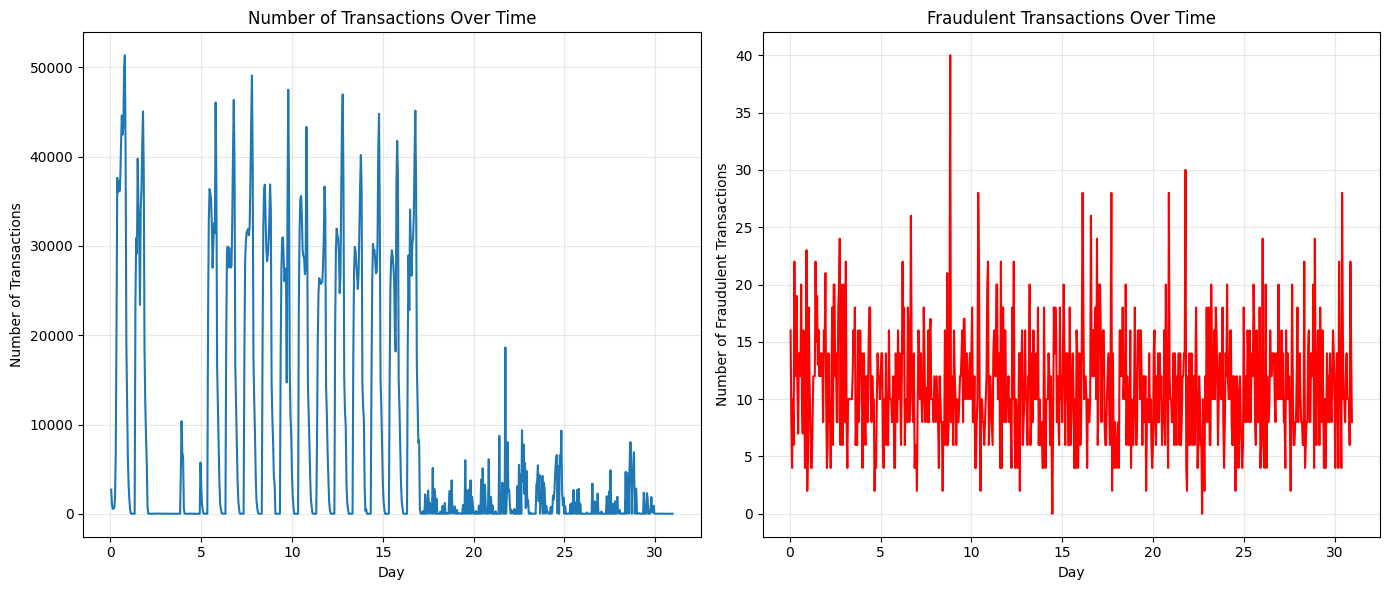

In [5]:
# Visualize transaction distribution over time (by day)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df.groupby('day').size().plot()
plt.title('Number of Transactions Over Time')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
fraud_by_time = df.groupby('day')['isFraud'].agg(['sum', 'mean'])
fraud_by_time['sum'].plot(color='red')
plt.title('Fraudulent Transactions Over Time')
plt.xlabel('Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

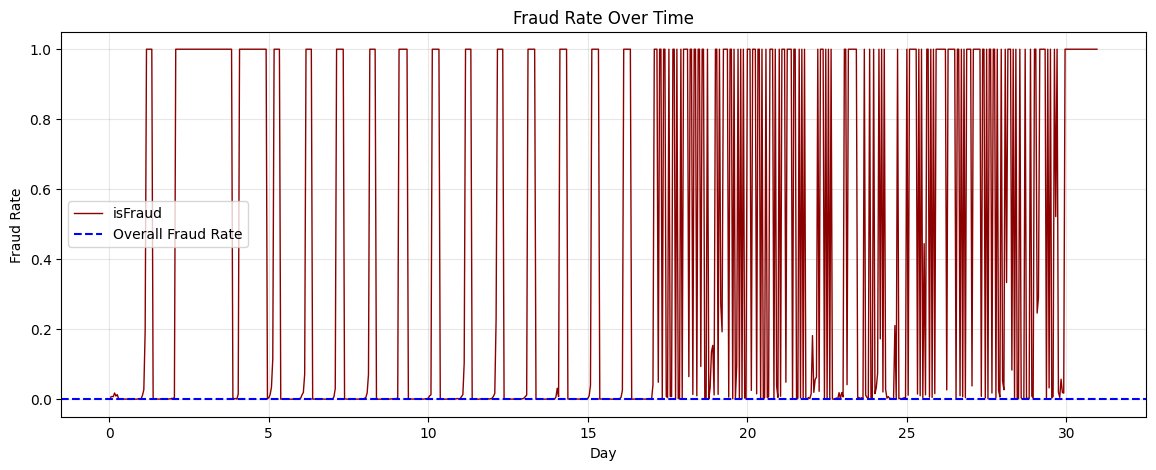

Overall fraud rate: 0.0013


In [6]:
# Check fraud rate over time
plt.figure(figsize=(14, 5))
fraud_rate = df.groupby('day')['isFraud'].mean()
fraud_rate.plot(color='darkred', linewidth=1)
plt.axhline(y=df['isFraud'].mean(), color='blue', linestyle='--', label='Overall Fraud Rate')
plt.title('Fraud Rate Over Time')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Overall fraud rate: {df['isFraud'].mean():.4f}")

## Sort Data by Time

Before splitting, we need to sort the data chronologically to maintain temporal ordering.

In [7]:
# Sort by time (step) to ensure chronological ordering
df_sorted = df.sort_values('step').reset_index(drop=True)

print(f"Data sorted by time (step)")
print(f"Total samples: {len(df_sorted):,}")
print(f"Time range: Day {df_sorted['day'].min():.1f} to Day {df_sorted['day'].max():.1f}")
print(f"\nFirst few rows after sorting:")
print(df_sorted[['step', 'day', 'type', 'amount', 'isFraud']].head())

Data sorted by time (step)
Total samples: 6,362,620
Time range: Day 0.0 to Day 31.0

First few rows after sorting:
   step       day     type   amount  isFraud
0     1  0.041667  PAYMENT  9839.64        0
1     1  0.041667  PAYMENT  5157.05        0
2     1  0.041667  PAYMENT  5746.44        0
3     1  0.041667  PAYMENT  5607.36        0
4     1  0.041667  PAYMENT  6360.79        0


## Fraud-Rate Balanced Split

Instead of fixed time percentages (70/15/15), we can adjust split boundaries to ensure similar fraud rates across all sets. This helps when fraud patterns change over time.

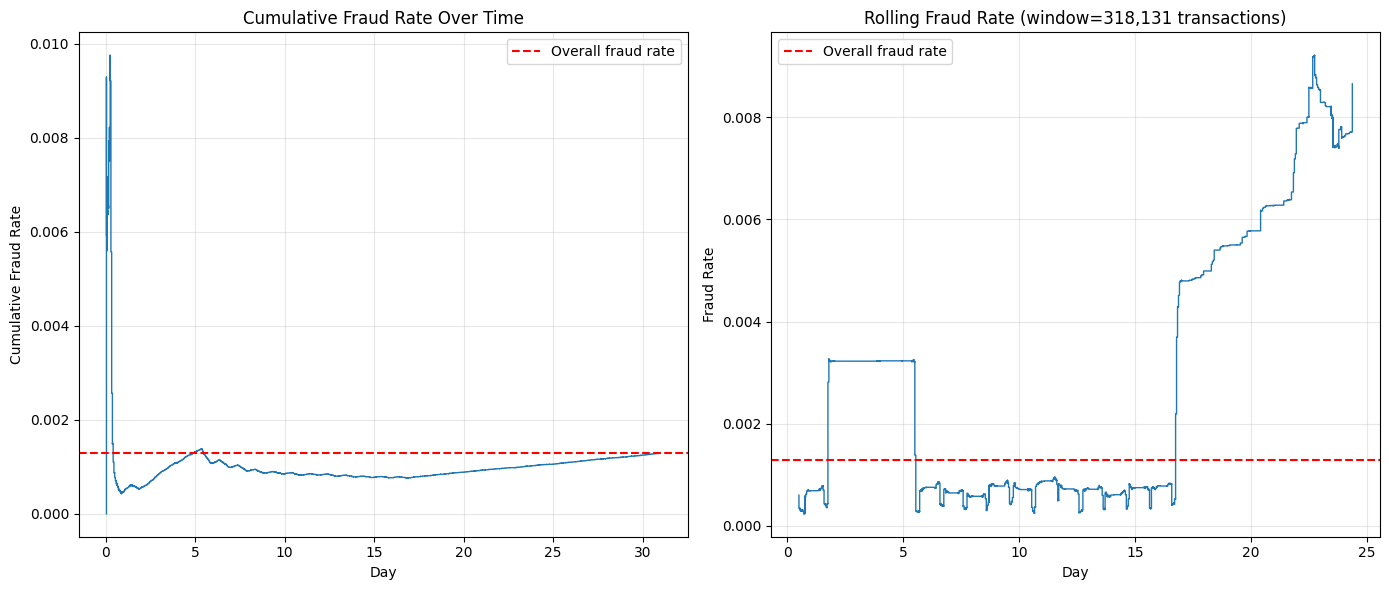


Fraud rate variation over time:
Overall fraud rate: 0.0013
Std deviation: 0.0014


In [8]:
# Analyze fraud rate over time to find balanced split points
df_sorted['cumulative_frauds'] = df_sorted['isFraud'].cumsum()
df_sorted['cumulative_total'] = range(1, len(df_sorted) + 1)
df_sorted['cumulative_fraud_rate'] = df_sorted['cumulative_frauds'] / df_sorted['cumulative_total']

# Plot cumulative fraud rate over time
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df_sorted['day'], df_sorted['cumulative_fraud_rate'], linewidth=1)
plt.axhline(y=df['isFraud'].mean(), color='red', linestyle='--', label='Overall fraud rate')
plt.title('Cumulative Fraud Rate Over Time')
plt.xlabel('Day')
plt.ylabel('Cumulative Fraud Rate')
plt.legend()
plt.grid(True, alpha=0.3)

# Show fraud rate in rolling windows
plt.subplot(1, 2, 2)
window_size = int(len(df_sorted) * 0.05)  # 5% rolling window
rolling_fraud_rate = df_sorted['isFraud'].rolling(window=window_size, center=True).mean()
plt.plot(df_sorted['day'], rolling_fraud_rate, linewidth=1)
plt.axhline(y=df['isFraud'].mean(), color='red', linestyle='--', label='Overall fraud rate')
plt.title(f'Rolling Fraud Rate (window={window_size:,} transactions)')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFraud rate variation over time:")
print(f"Overall fraud rate: {df['isFraud'].mean():.4f}")
print(f"Std deviation: {rolling_fraud_rate.std():.4f}")

In [9]:
# Sliding window algorithm to find optimal fraud-balanced splits
def find_fraud_balanced_splits_sliding_window(df, target_train_ratio=0.80, target_val_ratio=0.15, 
                                              window_size=10, step_size=10,
                                              objective='balanced', target_test_fraud_rate=None):
    """
    Use sliding window to find split points that balance fraud rates across sets.
    
    Parameters:
    - df: sorted dataframe
    - target_train_ratio: target proportion for training set
    - target_val_ratio: target proportion for validation set
    - window_size: size of each window to consider (transactions)
    - step_size: how much to slide the window each iteration
    - objective: 'balanced' (minimize variance), 'minimize_test' (lower test fraud), 
                 'maximize_train' (higher train fraud), or 'target' (hit specific test rate)
    - target_test_fraud_rate: when objective='target', aim for this fraud rate in test set
    
    Returns: optimal train_idx, val_idx, and score
    """
    total_samples = len(df)
    overall_fraud_rate = df['isFraud'].mean()
    
    # Define search ranges with flexibility
    train_min = int(total_samples * (target_train_ratio - 0.05))
    train_max = int(total_samples * (target_train_ratio + 0.05))
    
    best_train_idx = int(total_samples * target_train_ratio)
    best_val_idx = int(total_samples * (target_train_ratio + target_val_ratio))
    best_score = float('inf')
    
    # Precompute cumulative fraud counts for efficiency
    cumulative_frauds = df['isFraud'].cumsum().values
    
    def get_fraud_rate(start_idx, end_idx):
        """Calculate fraud rate efficiently using cumulative sums"""
        if start_idx == 0:
            fraud_count = cumulative_frauds[end_idx - 1]
        else:
            fraud_count = cumulative_frauds[end_idx - 1] - cumulative_frauds[start_idx - 1]
        return fraud_count / (end_idx - start_idx)
    
    print(f"Running sliding window search with objective: '{objective}'...")
    iterations = 0
    
    # Slide window for training set boundary
    for train_idx in range(train_min, train_max, step_size):
        if train_idx <= window_size or train_idx >= total_samples - window_size:
            continue
        
        # Calculate training fraud rate
        train_fraud_rate = get_fraud_rate(0, train_idx)
        
        # Define validation search range relative to train boundary
        val_min = train_idx + int(total_samples * (target_val_ratio - 0.03))
        val_max = train_idx + int(total_samples * (target_val_ratio + 0.03))
        val_min = max(train_idx + window_size, val_min)
        val_max = min(total_samples - window_size, val_max)
        
        # Slide window for validation set boundary
        for val_idx in range(val_min, val_max, step_size):
            iterations += 1
            
            # Calculate validation and test fraud rates
            val_fraud_rate = get_fraud_rate(train_idx, val_idx)
            test_fraud_rate = get_fraud_rate(val_idx, total_samples)
            
            rates = [train_fraud_rate, val_fraud_rate, test_fraud_rate]
            
            # Calculate score based on objective
            if objective == 'balanced':
                # Minimize variance across all splits
                fraud_variance = np.std(rates)
                score = fraud_variance
                
            elif objective == 'minimize_test':
                # Prioritize lower test fraud rate, then balance train/val
                test_penalty = test_fraud_rate * 100  # Heavy weight on test fraud
                train_val_variance = np.std([train_fraud_rate, val_fraud_rate])
                score = test_penalty + train_val_variance * 0.1
                
            elif objective == 'maximize_train':
                # Prioritize higher train fraud rate for more training examples
                train_reward = -train_fraud_rate * 100  # Negative = we want to minimize this (maximize train)
                val_test_variance = np.std([val_fraud_rate, test_fraud_rate])
                score = train_reward + val_test_variance * 0.1
                
            elif objective == 'target':
                # Try to hit a specific test fraud rate
                if target_test_fraud_rate is None:
                    target_test_fraud_rate = overall_fraud_rate * 0.8  # Default: 80% of overall
                test_distance = abs(test_fraud_rate - target_test_fraud_rate) * 1000
                train_val_variance = np.std([train_fraud_rate, val_fraud_rate])
                score = test_distance + train_val_variance * 0.1
            
            else:
                raise ValueError(f"Unknown objective: {objective}")
            
            # Penalty for deviating from target sizes (applies to all objectives)
            size_penalty = (
                abs(train_idx / total_samples - target_train_ratio) + 
                abs((val_idx - train_idx) / total_samples - target_val_ratio)
            ) * 0.0001  # Small weight
            
            score += size_penalty
            
            # Update best if improved
            if score < best_score:
                best_score = score
                best_train_idx = train_idx
                best_val_idx = val_idx
    
    print(f"Completed {iterations:,} iterations")
    return best_train_idx, best_val_idx, best_score

# Find optimal split points using sliding window
print("Searching for fraud-balanced split points using sliding window...")

# Choose your objective:
# 'balanced' - equal fraud rates across all splits (default)
# 'minimize_test' - lower fraud in test set
# 'maximize_train' - higher fraud in train set for more learning examples
# 'target' - aim for specific test fraud rate

optimal_train_idx, optimal_val_idx, variance_score = find_fraud_balanced_splits_sliding_window(
    df_sorted, 
    target_train_ratio=0.70, 
    target_val_ratio=0.15,
    window_size=1000,   # Larger window = fewer iterations
    step_size=200,     # Bigger steps = faster search
    objective='balanced'  # 🎯 Change this to adjust behavior
)

print(f"\nOptimal split indices found:")
print(f"Train end: index {optimal_train_idx:,} ({optimal_train_idx/len(df_sorted)*100:.2f}%)")
print(f"Val end: index {optimal_val_idx:,} ({optimal_val_idx/len(df_sorted)*100:.2f}%)")
print(f"Score: {variance_score:.6f}")

Searching for fraud-balanced split points using sliding window...
Running sliding window search with objective: 'balanced'...
Completed 6,074,438 iterations

Optimal split indices found:
Train end: index 4,135,702 (65.00%)
Val end: index 4,899,216 (77.00%)
Score: 0.001071


### TIP: Try Different Objectives

You can experiment with different split objectives:

```python
# Option 1: Balanced (equal fraud rates across all splits)
objective='balanced'

# Option 2: Minimize test fraud (lower fraud in test set)
objective='minimize_test'  

# Option 3: Maximize train fraud (more fraud examples for training)
objective='maximize_train'

# Option 4: Target specific test fraud rate
objective='target', target_test_fraud_rate=0.0010  # e.g., 0.10% fraud
```

Just change the `objective` parameter in the cell above and re-run!

In [10]:
# Create fraud-balanced splits
train_balanced = df_sorted.iloc[:optimal_train_idx].copy()
val_balanced = df_sorted.iloc[optimal_train_idx:optimal_val_idx].copy()
test_balanced = df_sorted.iloc[optimal_val_idx:].copy()

print("\n=== FRAUD-BALANCED SPLITS ===")
print(f"\nTraining set:")
print(f"  Size: {len(train_balanced):,} ({len(train_balanced)/len(df)*100:.2f}%)")
print(f"  Fraud rate: {train_balanced['isFraud'].mean():.4f}")
print(f"  Day range: {train_balanced['day'].min():.1f} to {train_balanced['day'].max():.1f}")

print(f"\nValidation set:")
print(f"  Size: {len(val_balanced):,} ({len(val_balanced)/len(df)*100:.2f}%)")
print(f"  Fraud rate: {val_balanced['isFraud'].mean():.4f}")
print(f"  Day range: {val_balanced['day'].min():.1f} to {val_balanced['day'].max():.1f}")

print(f"\nTest set:")
print(f"  Size: {len(test_balanced):,} ({len(test_balanced)/len(df)*100:.2f}%)")
print(f"  Fraud rate: {test_balanced['isFraud'].mean():.4f}")
print(f"  Day range: {test_balanced['day'].min():.1f} to {test_balanced['day'].max():.1f}")

# Check consistency of fraud rates
print("\n=== FRAUD RATE CONSISTENCY ===")
fraud_rates = [
    train_balanced['isFraud'].mean(),
    val_balanced['isFraud'].mean(),
    test_balanced['isFraud'].mean()

]
print(f"\nTo get 50/50 balance, use the resampling techniques in the next sections.")

print(f"Fraud rates: Train={fraud_rates[0]:.4f}, Val={fraud_rates[1]:.4f}, Test={fraud_rates[2]:.4f}")
print(f"It does NOT mean 50/50 fraud vs non-fraud balance within each set!")

print(f"Overall dataset fraud rate: {df['isFraud'].mean():.4f}")
print(f"\n NOTE: 'Fraud-balanced' means the fraud rates are SIMILAR across train/val/test.")
print(f"Std deviation across splits: {np.std(fraud_rates):.6f}")


=== FRAUD-BALANCED SPLITS ===

Training set:
  Size: 4,135,702 (65.00%)
  Fraud rate: 0.0008
  Day range: 0.0 to 12.6

Validation set:
  Size: 763,514 (12.00%)
  Fraud rate: 0.0006
  Day range: 12.6 to 14.5

Test set:
  Size: 1,463,404 (23.00%)
  Fraud rate: 0.0030
  Day range: 14.5 to 31.0

=== FRAUD RATE CONSISTENCY ===

To get 50/50 balance, use the resampling techniques in the next sections.
Fraud rates: Train=0.0008, Val=0.0006, Test=0.0030
It does NOT mean 50/50 fraud vs non-fraud balance within each set!
Overall dataset fraud rate: 0.0013

 NOTE: 'Fraud-balanced' means the fraud rates are SIMILAR across train/val/test.
Std deviation across splits: 0.001063


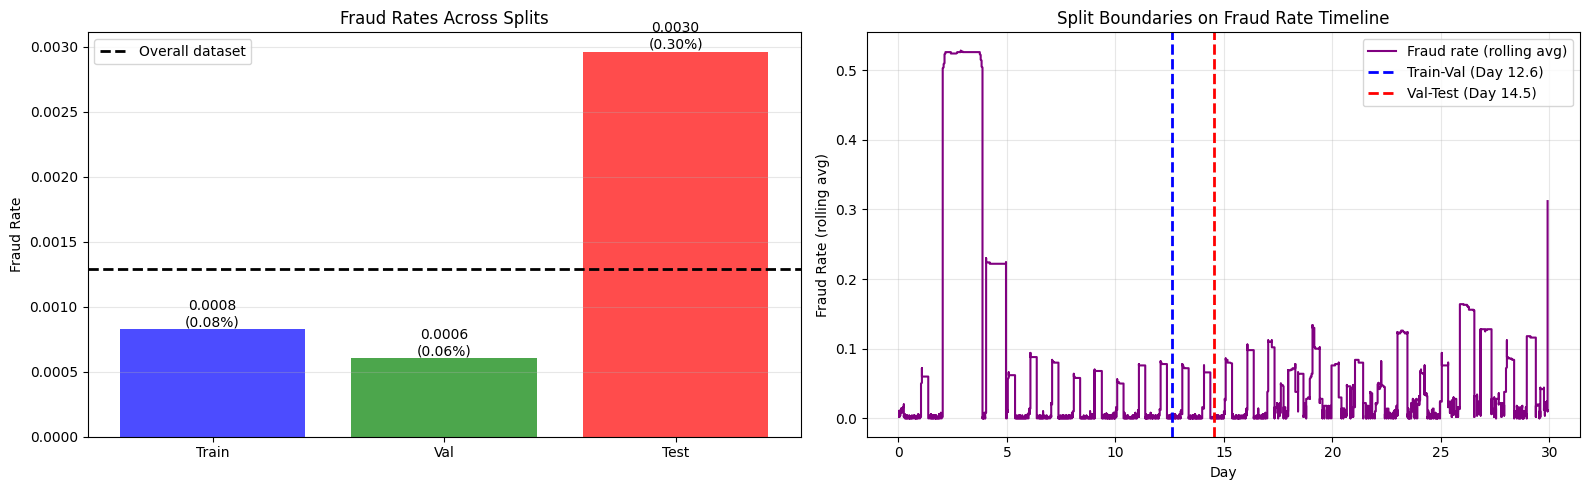


📊 The splits maintain similar fraud rates across train/val/test.
This ensures fair evaluation, but fraud is still ~0.13% (very imbalanced!)


In [11]:
# Visualize fraud rates and split boundaries
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Fraud rates comparison
splits_names = ['Train', 'Val', 'Test']
fraud_rates_balanced = [
    train_balanced['isFraud'].mean(),
    val_balanced['isFraud'].mean(),
    test_balanced['isFraud'].mean()
]

axes[0].bar(splits_names, fraud_rates_balanced, color=['blue', 'green', 'red'], alpha=0.7)
axes[0].axhline(y=df['isFraud'].mean(), color='black', linestyle='--', linewidth=2, label='Overall dataset')
axes[0].set_title('Fraud Rates Across Splits')
axes[0].set_ylabel('Fraud Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fraud_rates_balanced):
    axes[0].text(i, v, f'{v:.4f}\n({v*100:.2f}%)', ha='center', va='bottom')

# Plot 2: Split boundaries on fraud rate curve
train_end_day_bal = train_balanced['day'].max()
val_end_day_bal = val_balanced['day'].max()

axes[1].plot(df_sorted['day'], df_sorted['isFraud'].rolling(1000, center=True).mean(), 
             linewidth=1.5, color='purple', label='Fraud rate (rolling avg)')
axes[1].axvline(x=train_end_day_bal, color='blue', linestyle='--', linewidth=2, label=f'Train-Val (Day {train_end_day_bal:.1f})')
axes[1].axvline(x=val_end_day_bal, color='red', linestyle='--', linewidth=2, label=f'Val-Test (Day {val_end_day_bal:.1f})')
axes[1].set_title('Split Boundaries on Fraud Rate Timeline')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (rolling avg)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 The splits maintain similar fraud rates across train/val/test.")
print("This ensures fair evaluation, but fraud is still ~0.13% (very imbalanced!)")

In [14]:
# Save fraud-balanced splits
balanced_split_dir = "../data/splits"
os.makedirs(balanced_split_dir, exist_ok=True)

train_balanced.to_csv(os.path.join(balanced_split_dir, "train.csv"), index=False)
val_balanced.to_csv(os.path.join(balanced_split_dir, "val.csv"), index=False)
test_balanced.to_csv(os.path.join(balanced_split_dir, "test.csv"), index=False)

print(f"✅ Saved fraud-balanced splits to: {balanced_split_dir}")
print(f"\nFiles saved:")
print(f"  - train.csv: {len(train_balanced):,} samples")
print(f"  - val.csv: {len(val_balanced):,} samples")
print(f"  - test.csv: {len(test_balanced):,} samples")
print(f"\n⚠️ These splits have consistent fraud rates but are still highly imbalanced!")

print(f"Use resampling techniques below to balance the TRAINING set only.")
test_df = test_balanced.copy()
train_df = train_balanced.copy()
val_df = val_balanced.copy()

# Also assign to train_df, val_df, test_df for compatibility 

✅ Saved fraud-balanced splits to: ../data/splits

Files saved:
  - train.csv: 4,135,702 samples
  - val.csv: 763,514 samples
  - test.csv: 1,463,404 samples

⚠️ These splits have consistent fraud rates but are still highly imbalanced!
Use resampling techniques below to balance the TRAINING set only.


## Verify Split Quality

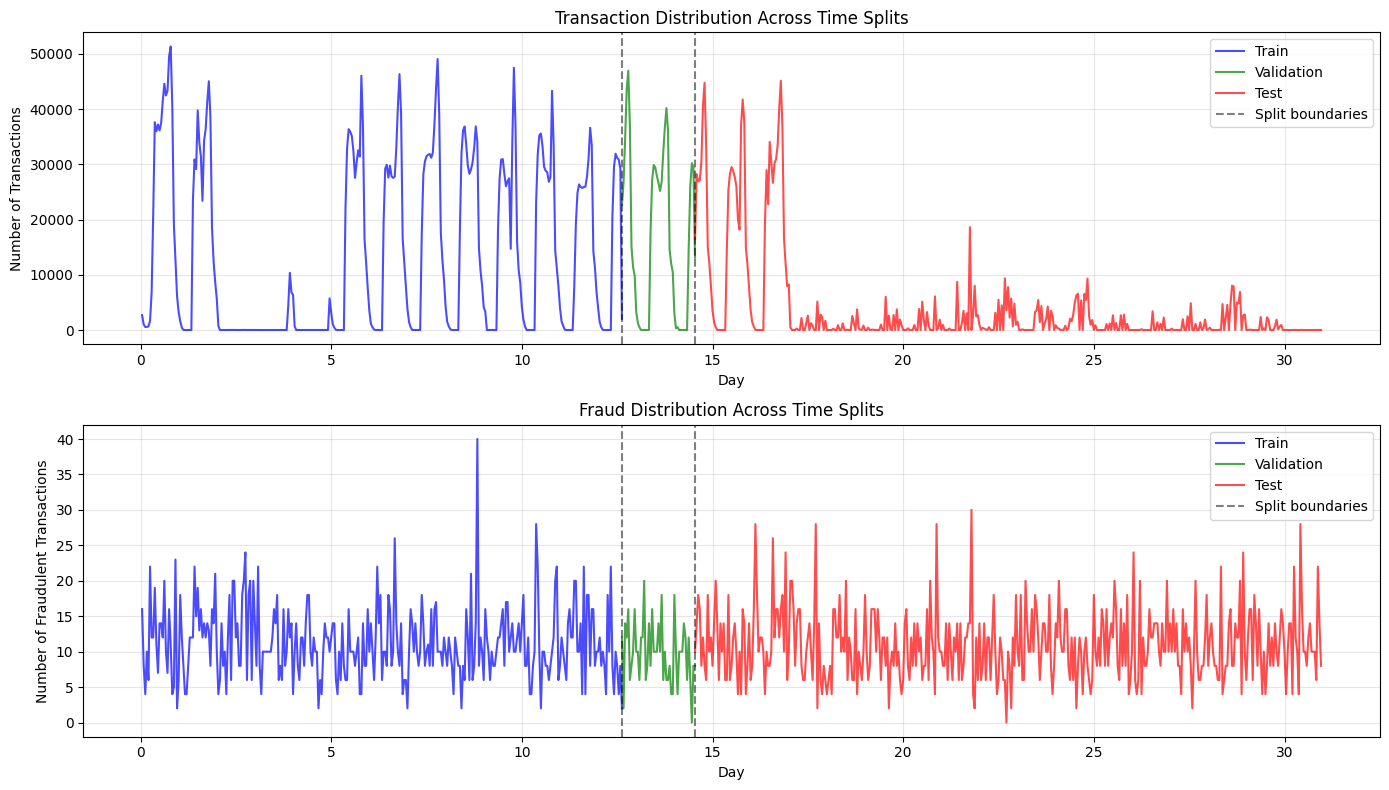

In [ ]:
# Visualize the split
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Transaction counts by day
train_counts = train_df.groupby('day').size()
val_counts = val_df.groupby('day').size()
test_counts = test_df.groupby('day').size()

axes[0].plot(train_counts.index, train_counts.values, label='Train', color='blue', alpha=0.7)
axes[0].plot(val_counts.index, val_counts.values, label='Validation', color='green', alpha=0.7)
axes[0].plot(test_counts.index, test_counts.values, label='Test', color='red', alpha=0.7)
axes[0].axvline(x=train_df['day'].max(), color='black', linestyle='--', alpha=0.5, label='Split boundaries')
axes[0].axvline(x=val_df['day'].max(), color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Transaction Distribution Across Time Splits')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Fraud counts by day
train_fraud = train_df.groupby('day')['isFraud'].sum()
val_fraud = val_df.groupby('day')['isFraud'].sum()
test_fraud = test_df.groupby('day')['isFraud'].sum()

axes[1].plot(train_fraud.index, train_fraud.values, label='Train', color='blue', alpha=0.7)
axes[1].plot(val_fraud.index, val_fraud.values, label='Validation', color='green', alpha=0.7)
axes[1].plot(test_fraud.index, test_fraud.values, label='Test', color='red', alpha=0.7)
axes[1].axvline(x=train_df['day'].max(), color='black', linestyle='--', alpha=0.5, label='Split boundaries')
axes[1].axvline(x=val_df['day'].max(), color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Fraud Distribution Across Time Splits')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Fraudulent Transactions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Check transaction type distribution
print("\nTransaction type distribution:")
print("\nTraining set:")
print(train_df['type'].value_counts(normalize=True))
print("\nValidation set:")
print(val_df['type'].value_counts(normalize=True))
print("\nTest set:")
print(test_df['type'].value_counts(normalize=True))


Transaction type distribution:

Training set:
type
CASH_OUT    0.355005
PAYMENT     0.337607
CASH_IN     0.218888
TRANSFER    0.082351
DEBIT       0.006149
Name: proportion, dtype: float64

Validation set:
type
CASH_OUT    0.348132
PAYMENT     0.336634
CASH_IN     0.221441
TRANSFER    0.086630
DEBIT       0.007163
Name: proportion, dtype: float64

Test set:
type
CASH_OUT    0.344062
PAYMENT     0.340459
CASH_IN     0.222056
TRANSFER    0.086227
DEBIT       0.007197
Name: proportion, dtype: float64


## Summary Statistics

In [ ]:
# Create a summary dataframe
summary_data = {
    'Dataset': ['Training', 'Validation', 'Test', 'Total'],
    'Size': [len(train_df), len(val_df), len(test_df), len(df)],
    'Fraud Count': [train_df['isFraud'].sum(), val_df['isFraud'].sum(), test_df['isFraud'].sum(), df['isFraud'].sum()],
    'Fraud Rate': [train_df['isFraud'].mean(), val_df['isFraud'].mean(), test_df['isFraud'].mean(), df['isFraud'].mean()],
    'Day Range (Min)': [train_df['day'].min(), val_df['day'].min(), test_df['day'].min(), df['day'].min()],
    'Day Range (Max)': [train_df['day'].max(), val_df['day'].max(), test_df['day'].max(), df['day'].max()]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Size %'] = (summary_df['Size'] / len(df) * 100).round(2)
summary_df['Fraud Rate'] = summary_df['Fraud Rate'].round(4)
summary_df['Day Range (Min)'] = summary_df['Day Range (Min)'].round(2)
summary_df['Day Range (Max)'] = summary_df['Day Range (Max)'].round(2)

print("\n=== SUMMARY ===")
print(summary_df.to_string(index=False))

# Save summary
summary_path = os.path.join(balanced_split_dir, "split_summary.csv")

summary_df.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")


=== SUMMARY ===
   Dataset    Size  Fraud Count  Fraud Rate  Day Range (Min)  Day Range (Max)  Size %
  Training 4135702         3415      0.0008             0.04            12.62    65.0
Validation  763514          462      0.0006            12.62            14.54    12.0
      Test 1463404         4336      0.0030            14.54            30.96    23.0
     Total 6362620         8213      0.0013             0.04            30.96   100.0

Summary saved to: ../data/splits/split_summary.csv


## Verify No Data Leakage

In [ ]:
# Verify temporal ordering
print("Verifying temporal ordering (no data leakage):")
print(f"Max day in training: {train_df['day'].max():.2f}")
print(f"Min day in validation: {val_df['day'].min():.2f}")
print(f"Max day in validation: {val_df['day'].max():.2f}")
print(f"Min day in test: {test_df['day'].min():.2f}")

print(f"\nMax step (hour) in training: {train_df['step'].max()}")
print(f"Min step (hour) in validation: {val_df['step'].min()}")
print(f"Max step (hour) in validation: {val_df['step'].max()}")
print(f"Min step (hour) in test: {test_df['step'].min()}")

# Check for overlaps using step (hour) - more precise than day
train_val_no_overlap = train_df['step'].max() <= val_df['step'].min()
val_test_no_overlap = val_df['step'].max() <= test_df['step'].min()

if train_val_no_overlap and val_test_no_overlap:
    print("\n✅ Temporal ordering is correct. Train ≤ Validation ≤ Test (no data leakage)")
    if train_df['step'].max() == val_df['step'].min():
        print("   Note: Train and Val share the same boundary hour (this is fine)")
    if val_df['step'].max() == test_df['step'].min():
        print("   Note: Val and Test share the same boundary hour (this is fine)")
else:
    print("\n⚠️ Warning: Actual temporal overlap detected! There may be data leakage.")

Verifying temporal ordering (no data leakage):
Max day in training: 12.62
Min day in validation: 12.62
Max day in validation: 14.54
Min day in test: 14.54

Max step (hour) in training: 303
Min step (hour) in validation: 303
Max step (hour) in validation: 349
Min step (hour) in test: 349

✅ Temporal ordering is correct. Train ≤ Validation ≤ Test (no data leakage)
   Note: Train and Val share the same boundary hour (this is fine)
   Note: Val and Test share the same boundary hour (this is fine)
